In [1]:
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

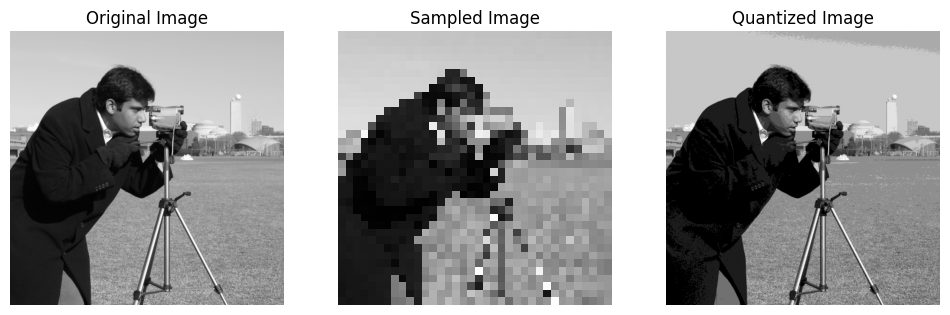

In [4]:
original_image = data.camera()

sampling_factor = 14
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

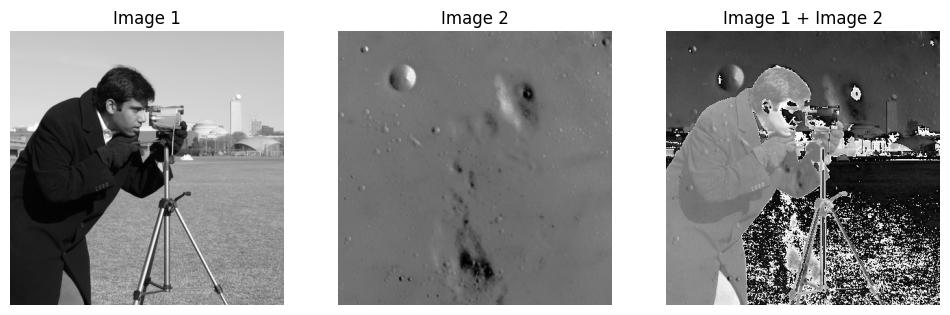

In [5]:
img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
result_image = Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

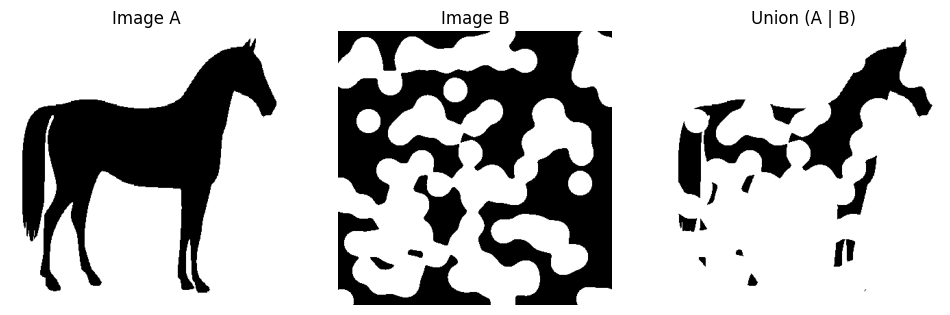

In [6]:
img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

#Task 1


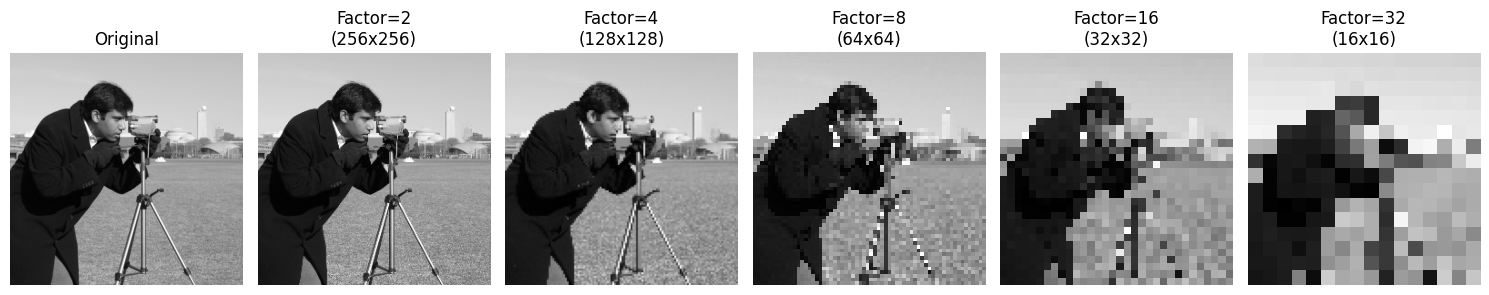

In [7]:
sampling_factors = [2, 4, 8, 16, 32]

plt.figure(figsize=(15, 4))
plt.subplot(1, len(sampling_factors) + 1, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, factor in enumerate(sampling_factors, start=2):
    sampled = sample_image(original_image, factor)
    plt.subplot(1, len(sampling_factors) + 1, i)
    plt.imshow(sampled, cmap='gray')
    plt.title(f'Factor={factor}\n({sampled.shape[1]}x{sampled.shape[0]})')
    plt.axis('off')

plt.tight_layout()
plt.show()

###  Effect of quantization levels (intensity resolution)

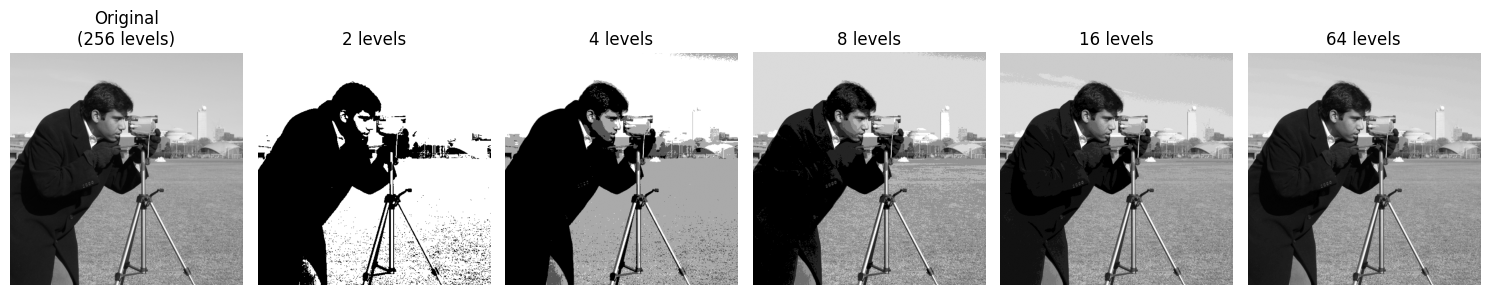

In [8]:
quant_levels_list = [2, 4, 8, 16, 64]

plt.figure(figsize=(15, 4))
plt.subplot(1, len(quant_levels_list) + 1, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original\n(256 levels)')
plt.axis('off')

for i, levels in enumerate(quant_levels_list, start=2):
    q = quantize_image(original_image, levels)
    plt.subplot(1, len(quant_levels_list) + 1, i)
    plt.imshow(q, cmap='gray')
    plt.title(f'{levels} levels')
    plt.axis('off')

plt.tight_layout()
plt.show()

#Task 2
Subtract two images


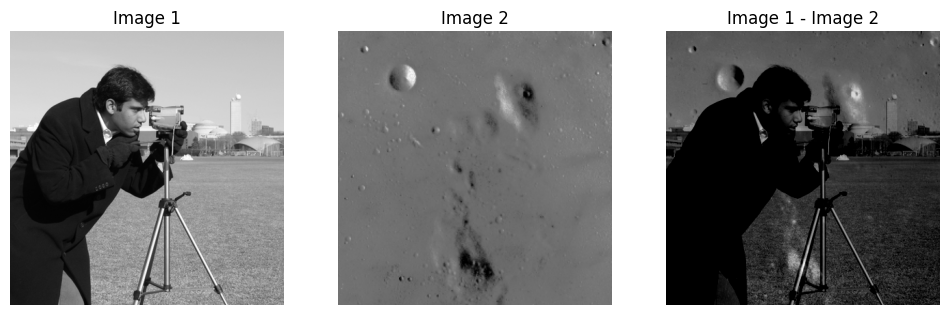

In [9]:
subtraction = cv2.subtract(im1arr, im2arr)   # clips negative results to 0
result_image_sub = Image.fromarray(subtraction)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_sub, cmap='gray'), plt.title('Image 1 - Image 2'), plt.axis('off')
plt.show()

Add image with constant value 175

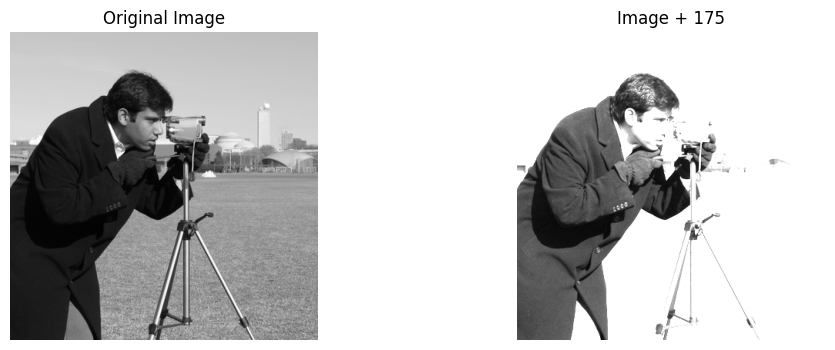

In [10]:
constant_value = 175


brightened = cv2.add(im1arr, np.full(im1arr.shape, constant_value, dtype=np.uint8))
result_image_const = Image.fromarray(brightened)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1), plt.imshow(img1, cmap='gray'), plt.title('Original Image'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(result_image_const, cmap='gray'), plt.title(f'Image + {constant_value}'), plt.axis('off')
plt.show()

Set operations on grayscale images

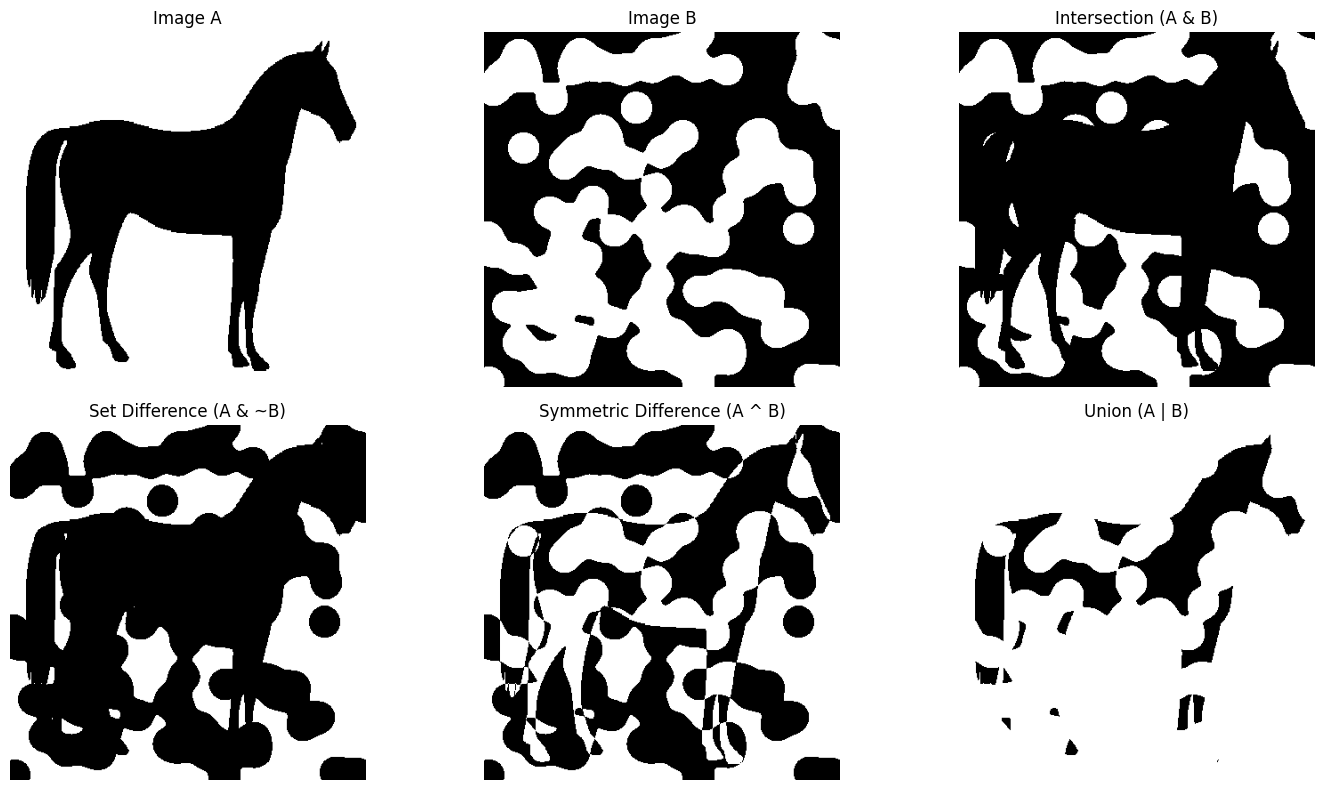

In [12]:
imA = np.asarray(img3.convert('L'))
imB = np.asarray(img4.convert('L'))

intersection = cv2.bitwise_and(imA, imB)
set_difference = cv2.bitwise_and(imA, cv2.bitwise_not(imB))
symmetric_difference = cv2.bitwise_xor(imA, imB)
union_op = cv2.bitwise_or(imA, imB)

titles = ['Image A', 'Image B', 'Intersection (A & B)',
          'Set Difference (A & ~B)', 'Symmetric Difference (A ^ B)', 'Union (A | B)']
images_to_show = [imA, imB, intersection, set_difference, symmetric_difference, union_op]

plt.figure(figsize=(15, 8))
for i, (title, im) in enumerate(zip(titles, images_to_show), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(im, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()
